In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
from src.misc.metrics import *

result_folder = "results/RTX-4090_r2/llama3.2-vision_11b-qwen2.5_14b"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

{'task_completion_rate': 1,
 'task_success_rate': 0.9797979797979798,
 'total_execution_time': 23822.612327,
 'mean_execution_time': 12.031622387373737,
 'std_execution_time': 9.303616568095457,
 'mean_process_steps': 8.641414141414142,
 'std_process_steps': 1.9655193503309853,
 'total_tasks': 1980,
 'SUCCESS': 1940,
 'DB_QUERY_TOOL_NOT_INITIALIZED': 24,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 15,
 'OCR_TOOL_RESULT_MISMATCH': 1}

In [5]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,...,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,process_steps,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-11 02:12:38.750452,2025-04-11 02:19:10.089497,...,391.3390,6,2394,2024,370,0.0,SUCCESS,9,391.339045,0 days 00:06:31
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-11 02:19:10.093741,2025-04-11 02:19:21.394290,...,11.3005,6,2353,2037,316,0.0,SUCCESS,9,11.300549,0 days 00:00:11
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-11 02:19:21.398584,2025-04-11 02:19:38.180195,...,16.7816,6,2427,2015,412,0.0,SUCCESS,9,16.781611,0 days 00:00:16
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-11 02:19:38.184001,2025-04-11 02:19:49.155206,...,10.9712,6,2302,2009,293,0.0,SUCCESS,9,10.971205,0 days 00:00:10
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-11 02:19:49.158987,2025-04-11 02:20:03.572407,...,14.4134,6,2362,2041,321,0.0,SUCCESS,9,14.413420,0 days 00:00:14


In [6]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

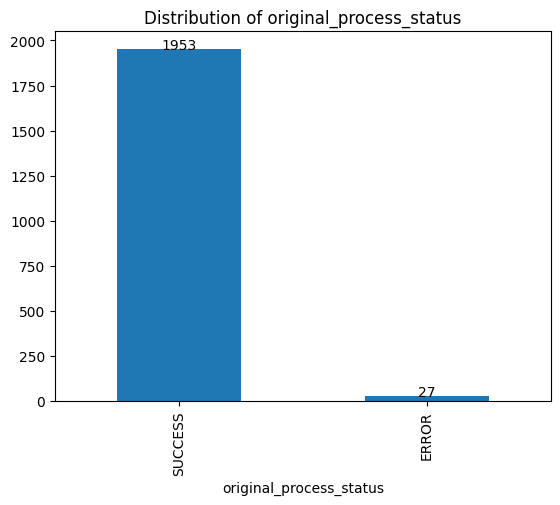

In [7]:
plot_value_distribution(df, "original_process_status")

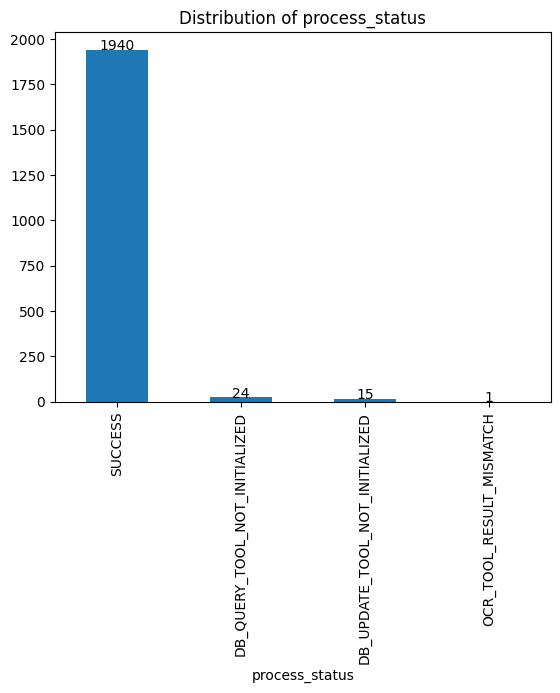

In [8]:
plot_value_distribution(df, "process_status")

In [9]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: SUCCESS
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-04-11 02:12:38.750452
--------------------------------------------------
end_time: 2025-04-11 02:19:10.089497
-----------------------------------------

In [10]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

9

In [11]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-11T02:12:38.750452",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-11T02:18:55.329751",


In [12]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 538\\nSent by: Robin Levine\\nYou paid $196 to Tanya\\nTransaction Reference Number: EC4F9FE854344D25\\nTransaction Date: 04/23/23\\nInvoice ID: 43925\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 139, \"prompt_tokens\": 90, \"completion_tokens\": 49, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-11T02:18:55.329751",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"43925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"EC4F9FE854344D25\", \"amount\": \"$196.00\", \"rec

3

In [13]:
df["process_status"].value_counts()

process_status
SUCCESS                           1940
DB_QUERY_TOOL_NOT_INITIALIZED       24
DB_UPDATE_TOOL_NOT_INITIALIZED      15
OCR_TOOL_RESULT_MISMATCH             1
Name: count, dtype: int64

In [14]:
df_filtered = (
    df[df["attachments"] == ""].copy().reset_index(drop=True)
)
len(df_filtered)

990

In [15]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: E-93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 1043925
--------------------------------------------------
email_body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1043925, related to our recent order with you. Here are the details:  
Invoice ID: 1043925
Invoice Date: 4/23/23
Total Amount paid: 196.0
Transaction Reference Number - T-EC4F9FE854344D25
Thank you and I look forward to our continued business
Best regards,
Robin Levine
--------------------------------------------------
attachments: 
--------------------------------------------------
process_status: SUCCESS
----------

In [16]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

8

In [17]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 1043925\n            Body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1043925, related to our recent order with you. Here are the details:  \nInvoice ID: 1043925\nInvoice Date: 4/23/23\nTotal Amount paid: 196.0\nTransaction Reference Number - T-EC4F9FE854344D25\nThank you and I look forward to our continued business\nBest regards,\nRobin Levine\n            \n            \n                ",
    "timestamp": "2025-04-11T06:03:32.850439",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output

In [18]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"1043925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"T-EC4F9FE854344D25\", \"amount\": \"$196.00\", \"recipient_name\": \"Tanya\", \"sender_name\": \"Robin Levine\"}}",
    "timestamp": "2025-04-11T06:03:35.711788",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_update_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"DONE\"}",
    "timestamp": "2025-04-11T06:03:39.925520",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
   

2

In [19]:
df_filtered = (
    df[df["process_status"] == "OCR_TOOL_RESULT_MISMATCH"].copy().reset_index(drop=True)
)
len(df_filtered)

1

In [20]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: 1DB13CBF8EF746BFB329E0F89C73600E
--------------------------------------------------
sender_email: JamesPhillips@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 57267
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 57267 , Regards James Phillips
--------------------------------------------------
attachments: transaction_589.jpeg
--------------------------------------------------
process_status: OCR_TOOL_RESULT_MISMATCH
--------------------------------------------------
response: ERROR The email and OCR data provided does not contain the invoice amount that needs to be reconciled with the database. The email mentions Invoice ID: 57267 but there is no mention of an invoice amount, and the OCR 

In [21]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

4

In [22]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: JamesPhillips@example.com\n            Subject: Payment Confirmation for Invoice ID: 57267\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 57267 , Regards James Phillips\n            Attachment: transaction_589.jpeg\n            \n                ",
    "timestamp": "2025-04-11T04:32:17.129924",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-11T04:32:17.937

In [23]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"**Bank Information**\\n* Bank Name: Bank 617\\n* Sent by: James Phillips\\n\\n**Transaction Details**\\n* Payment Amount: $89\\n* Recipient: Tanya\\n\\n**Reference Number and Date**\\n* Transaction Reference Number: F5497136AF6746B2\\n* Transaction Date: April 20, 2023\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 160, \"prompt_tokens\": 90, \"completion_tokens\": 70, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-11T04:32:17.937613",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}


1

In [27]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 57267"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [28]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 57267
--------------------------------------------------
bank_name: Bank 617
--------------------------------------------------
transaction_id: F5497136AF6746B2
--------------------------------------------------
amount: 89.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: James Phillips
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [29]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

34